# GHG Emissions Intensity Modeling

This notebook now separates two related tasks:

1. **Forecasting**: predict GHG intensity from building characteristics without fuel-intensity inputs.
2. **Estimation / imputation**: estimate GHG intensity when fuel-derived inputs are available.

The primary headline evaluation uses a **year-based holdout**. A separate **grouped building holdout** is added to avoid putting the same building in both train and test.


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)

DATA_PATH = Path("NYC_Building_Energy_and_Water_Data_Disclosure_shared_cleaned.csv")
TARGET = "Total (Location-Based) GHG Emissions Intensity (kgCO2e/ft²)"
CURRENT_YEAR = 2026
MIN_CATEGORY_COUNT = 200
YEAR_COL = "Calendar Year"
PRIMARY_HOLDOUT_YEAR = 2024
GROUP_TEST_SIZE = 0.2
PERMUTATION_SAMPLE_SIZE = 1500

IDENTIFIER_COLUMNS = [
    "Property ID",
    "NYC Borough, Block and Lot (BBL)",
    "NYC Building Identification Number (BIN)",
]

BUILDING_NUMERIC_COLUMNS = [
    "Calendar Year",
    "Year Built",
    "Property GFA - Self-Reported (ft²)",
    "Largest Property Use Type - Gross Floor Area (ft²)",
    "Number of Buildings",
    "Occupancy",
]

BUILDING_CATEGORICAL_COLUMNS = [
    "Primary Property Type - Self Selected",
    "Largest Property Use Type",
]

FUEL_USE_COLUMNS = [
    "Electricity Use - Grid Purchase (kBtu)",
    "Natural Gas Use (kBtu)",
    "District Steam Use (kBtu)",
    "District Hot Water Use (kBtu)",
    "District Chilled Water Use (kBtu)",
    "Fuel Oil #1 Use (kBtu)",
    "Fuel Oil #2 Use (kBtu)",
    "Fuel Oil #4 Use (kBtu)",
    "Fuel Oil #5 & 6 Use (kBtu)",
    "Diesel #2 Use (kBtu)",
    "Propane Use (kBtu)",
    "Kerosene Use (kBtu)",
]



## Data Loading And Cleaning Helpers

In [2]:
def make_feature_slug(name: str) -> str:
    slug = name.lower()
    slug = slug.replace("(kbtu)", "")
    slug = slug.replace("(ft²)", "")
    slug = slug.replace("use", "")
    slug = slug.replace(" - ", "_")
    slug = re.sub(r"[^a-z0-9]+", "_", slug)
    return slug.strip("_")


def to_numeric(series: pd.Series) -> pd.Series:
    cleaned = series.astype(str).str.replace(",", "", regex=False)
    cleaned = cleaned.replace({"Not Available": np.nan, "nan": np.nan, "None": np.nan})
    return pd.to_numeric(cleaned, errors="coerce")


def load_shared_dataset(data_path: Path) -> pd.DataFrame:
    if not data_path.exists():
        raise FileNotFoundError(
            f"Missing required input file: {data_path}. "
            "Run Shared_EDA.ipynb first to export the shared-cleaned CSV."
        )

    raw_df = pd.read_csv(data_path, low_memory=False)
    if TARGET not in raw_df.columns:
        raise KeyError(f"Required target column not found: {TARGET}")

    requested_columns = [
        TARGET,
        *IDENTIFIER_COLUMNS,
        *BUILDING_NUMERIC_COLUMNS,
        *BUILDING_CATEGORICAL_COLUMNS,
        *FUEL_USE_COLUMNS,
    ]
    available_columns = [col for col in requested_columns if col in raw_df.columns]
    missing_columns = [col for col in requested_columns if col not in raw_df.columns]

    if missing_columns:
        print("Missing columns skipped:")
        for col in missing_columns:
            print("-", col)
        print()

    df = raw_df[available_columns].copy()
    numeric_columns = [col for col in [TARGET, *BUILDING_NUMERIC_COLUMNS, *FUEL_USE_COLUMNS] if col in df.columns]
    for col in numeric_columns:
        df[col] = to_numeric(df[col])
    return df


def clean_anomalies(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()

    if "Year Built" in cleaned.columns:
        cleaned.loc[(cleaned["Year Built"] < 1800) | (cleaned["Year Built"] > CURRENT_YEAR), "Year Built"] = np.nan

    if "Occupancy" in cleaned.columns:
        cleaned.loc[(cleaned["Occupancy"] < 0) | (cleaned["Occupancy"] > 100), "Occupancy"] = np.nan

    if "Number of Buildings" in cleaned.columns:
        cleaned.loc[cleaned["Number of Buildings"] <= 0, "Number of Buildings"] = np.nan

    for col in [
        "Property GFA - Self-Reported (ft²)",
        "Largest Property Use Type - Gross Floor Area (ft²)",
    ]:
        if col in cleaned.columns:
            cleaned.loc[cleaned[col] <= 0, col] = np.nan

    for col in [fuel_col for fuel_col in FUEL_USE_COLUMNS if fuel_col in cleaned.columns]:
        cleaned.loc[cleaned[col] < 0, col] = np.nan

    cleaned.loc[cleaned[TARGET] <= 0, TARGET] = np.nan
    return cleaned


## Feature Engineering

In [3]:
def build_stable_building_id(frame: pd.DataFrame) -> pd.Series:
    stable_id = pd.Series(pd.NA, index=frame.index, dtype="string")
    for col in IDENTIFIER_COLUMNS:
        if col in frame.columns:
            candidate = frame[col].astype("string").replace({"<NA>": pd.NA, "nan": pd.NA, "None": pd.NA})
            stable_id = stable_id.fillna(candidate)
    fallback = pd.Series([f"row_{idx}" for idx in frame.index], index=frame.index, dtype="string")
    return stable_id.fillna(fallback)


def build_property_type(frame: pd.DataFrame) -> pd.Series:
    property_type = pd.Series(pd.NA, index=frame.index, dtype="object")
    for col in ["Primary Property Type - Self Selected", "Largest Property Use Type"]:
        if col in frame.columns:
            property_type = property_type.fillna(frame[col])
    return property_type.fillna("Missing").astype(str)


def engineer_features(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str], list[str]]:
    model_df = df.copy()
    fuel_columns = [col for col in FUEL_USE_COLUMNS if col in model_df.columns]
    if not fuel_columns:
        raise ValueError("No fuel-use columns were found, so the fuel-mix model cannot be built.")

    model_df["Stable Building ID"] = build_stable_building_id(model_df)
    model_df["Property Type for Modeling"] = build_property_type(model_df)

    model_df["Model GFA (ft²)"] = model_df["Property GFA - Self-Reported (ft²)"]
    if "Largest Property Use Type - Gross Floor Area (ft²)" in model_df.columns:
        model_df["Model GFA (ft²)"] = model_df["Model GFA (ft²)"].fillna(
            model_df["Largest Property Use Type - Gross Floor Area (ft²)"]
        )
    model_df.loc[model_df["Model GFA (ft²)"] <= 0, "Model GFA (ft²)"] = np.nan

    if "Largest Property Use Type - Gross Floor Area (ft²)" in model_df.columns:
        model_df["Largest Use Share of GFA"] = (
            model_df["Largest Property Use Type - Gross Floor Area (ft²)"] / model_df["Model GFA (ft²)"]
        )
    else:
        model_df["Largest Use Share of GFA"] = np.nan

    missing_flag_features = []
    intensity_features = []
    share_features = []

    for col in fuel_columns:
        feature_prefix = make_feature_slug(col)
        missing_flag = f"{feature_prefix}_missing"
        intensity_feature = f"{feature_prefix}_intensity"
        share_feature = f"{feature_prefix}_share"

        model_df[missing_flag] = model_df[col].isna().astype(int)
        missing_flag_features.append(missing_flag)

        model_df[col] = model_df[col].fillna(0.0)
        intensity_features.append(intensity_feature)
        share_features.append(share_feature)

    model_df["Total Fuel Use (kBtu)"] = model_df[fuel_columns].sum(axis=1)
    model_df["Largest Use Share of GFA"] = model_df["Largest Use Share of GFA"].replace([np.inf, -np.inf], np.nan)

    for col in fuel_columns:
        feature_prefix = make_feature_slug(col)
        intensity_feature = f"{feature_prefix}_intensity"
        share_feature = f"{feature_prefix}_share"

        model_df[intensity_feature] = model_df[col] / model_df["Model GFA (ft²)"]
        model_df[intensity_feature] = model_df[intensity_feature].replace([np.inf, -np.inf], np.nan).fillna(0.0)

        model_df[share_feature] = model_df[col] / model_df["Total Fuel Use (kBtu)"]
        model_df[share_feature] = model_df[share_feature].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    numeric_features = [
        "Calendar Year",
        "Year Built",
        "Number of Buildings",
        "Occupancy",
        "Model GFA (ft²)",
        "Largest Use Share of GFA",
    ]
    numeric_features = [col for col in numeric_features if col in model_df.columns]
    numeric_features.extend(intensity_features)
    numeric_features.extend(share_features)
    numeric_features.extend(missing_flag_features)

    categorical_features = ["Property Type for Modeling"]
    return model_df, numeric_features, categorical_features


def build_model_subset(df: pd.DataFrame) -> pd.DataFrame:
    subset = df.dropna(subset=[TARGET, "Model GFA (ft²)", YEAR_COL]).copy()
    subset[YEAR_COL] = subset[YEAR_COL].astype(int)
    if subset.empty:
        raise ValueError("No rows remain after the initial target, area, and year filters.")
    return subset


def print_dataset_snapshot(df: pd.DataFrame, model_df: pd.DataFrame) -> None:
    print("Initial rows:", len(df))
    print("Modeling rows after cleaning and filtering:", len(model_df))
    print("Unique Stable Building IDs:", model_df["Stable Building ID"].nunique())
    print()
    print("Rows by year:")
    print(model_df[YEAR_COL].value_counts().sort_index())
    print()
    print("Target summary:")
    print(model_df[TARGET].describe())
    print()


def plot_target_distribution(model_df: pd.DataFrame) -> None:
    target_values = model_df[TARGET].dropna()
    target_p99 = target_values.quantile(0.99)
    target_trimmed = target_values[target_values <= target_p99]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    sns.boxplot(x=target_values, showfliers=False, color="steelblue", ax=axes[0])
    axes[0].set_title("Boxplot (outliers hidden)")
    axes[0].set_xlabel(TARGET)

    sns.histplot(target_trimmed, bins=40, color="steelblue", ax=axes[1])
    axes[1].set_title("Histogram (up to 99th percentile)")
    axes[1].set_xlabel(TARGET)

    plt.tight_layout()
    plt.show()



## Evaluation And Diagnostic Helpers

In [4]:
"""Utilities to strengthen the GHG emissions intensity notebook.

This module is designed as a drop-in companion to the notebook. It focuses on:
- separating estimation vs forecasting feature sets
- fitting category grouping on the training fold only
- using model-specific preprocessors
- adding year-based holdout evaluation
- diagnosing transformed-target prediction explosions
- plotting without outlier-dominated axes
- subgroup error analysis
- permutation importance on a sampled test set

The code uses only pandas/numpy/matplotlib/scikit-learn.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """Collapse infrequent categories to 'Other' using training-fold counts only.

    This avoids fitting the rare-category grouping on the full dataset before the split.
    It supports pandas DataFrame, pandas Series, numpy arrays, and sklearn pipeline inputs.
    """

    def __init__(
        self,
        min_count: int = 200,
        other_label: str = "Other",
        missing_label: str = "Missing",
    ) -> None:
        self.min_count = int(min_count)
        self.other_label = other_label
        self.missing_label = missing_label

    def fit(self, X: Any, y: Any = None) -> "RareCategoryGrouper":
        X_df = self._to_frame(X)
        self.columns_ = list(X_df.columns)
        self.keepers_ = {}
        for col in self.columns_:
            counts = X_df[col].value_counts(dropna=True)
            keepers = set(counts[counts >= self.min_count].index.tolist())
            self.keepers_[col] = keepers
        return self

    def transform(self, X: Any) -> pd.DataFrame:
        X_df = self._to_frame(X, columns=getattr(self, "columns_", None)).copy()
        for col in X_df.columns:
            series = X_df[col].astype("object")
            keepers = self.keepers_.get(col, set())
            grouped = series.where(series.isin(keepers), self.other_label)
            X_df[col] = grouped.where(~series.isna(), self.missing_label)
        return X_df

    @staticmethod
    def _to_frame(X: Any, columns: Optional[list[str]] = None) -> pd.DataFrame:
        if isinstance(X, pd.DataFrame):
            return X.copy()
        if isinstance(X, pd.Series):
            name = X.name if X.name is not None else "feature"
            return X.to_frame(name=name)
        return pd.DataFrame(X, columns=columns)


class PropertyTypeMeanRegressor(BaseEstimator, RegressorMixin):
    """Baseline regressor that predicts the training mean per property-type group."""

    def __init__(
        self,
        property_type_col: str,
        global_strategy: str = "mean",
    ) -> None:
        self.property_type_col = property_type_col
        self.global_strategy = global_strategy

    def fit(self, X: Any, y: Any) -> "PropertyTypeMeanRegressor":
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        if self.property_type_col not in X.columns:
            raise KeyError(f"Missing property-type column: {self.property_type_col}")

        y_series = pd.Series(np.asarray(y, dtype=float), index=X.index, name="target")
        property_type = X[self.property_type_col].astype("object").fillna("Missing")

        if self.global_strategy == "median":
            self.global_value_ = float(np.median(y_series))
        else:
            self.global_value_ = float(np.mean(y_series))

        self.group_means_ = (
            pd.DataFrame({"property_type": property_type, "target": y_series})
            .groupby("property_type")["target"]
            .mean()
            .to_dict()
        )
        return self

    def predict(self, X: Any) -> np.ndarray:
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        if self.property_type_col not in X.columns:
            raise KeyError(f"Missing property-type column: {self.property_type_col}")

        property_type = X[self.property_type_col].astype("object").fillna("Missing")
        pred = property_type.map(self.group_means_).fillna(self.global_value_)
        return pred.to_numpy(dtype=float)


@dataclass
class ModelArtifacts:
    name: str
    model: Any
    predictions: np.ndarray
    metrics: dict[str, float]


def build_feature_scenarios(
    numeric_features: list[str],
    categorical_features: list[str],
) -> dict[str, dict[str, list[str]]]:
    """Build clearer scenario buckets for estimation vs forecasting.

    estimation_full:
        Keeps all current engineered features.
    estimation_without_intensities:
        Keeps metadata plus fuel shares/missingness, but excludes fuel intensities.
    forecasting_strict:
        Removes fuel-derived intensity/share/missing indicators so the model relies
        on building metadata only.
    fuel_derived_only:
        Keeps the fuel-derived engineered features only.
    """

    fuel_intensity = [c for c in numeric_features if c.endswith("_intensity")]
    fuel_share = [c for c in numeric_features if c.endswith("_share")]
    fuel_missing = [c for c in numeric_features if c.endswith("_missing")]
    fuel_derived = fuel_intensity + fuel_share + fuel_missing
    metadata_only = [c for c in numeric_features if c not in set(fuel_derived)]
    non_intensity_fuel = fuel_share + fuel_missing

    return {
        "estimation_full": {
            "numeric": list(numeric_features),
            "categorical": list(categorical_features),
        },
        "estimation_without_intensities": {
            "numeric": metadata_only + non_intensity_fuel,
            "categorical": list(categorical_features),
        },
        "forecasting_strict": {
            "numeric": metadata_only,
            "categorical": list(categorical_features),
        },
        "fuel_derived_only": {
            "numeric": fuel_derived,
            "categorical": [],
        },
    }


def build_linear_preprocessor(
    numeric_features: list[str],
    categorical_features: list[str],
    min_category_count: int = 200,
) -> ColumnTransformer:
    """Preprocessor for linear / GLM models.

    - Median imputation + scaling for numeric columns.
    - Rare-category grouping fit on the training fold.
    - Sparse one-hot output to reduce memory use.
    """

    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipe = Pipeline(
        steps=[
            ("rare", RareCategoryGrouper(min_count=min_category_count)),
            (
                "onehot",
                OneHotEncoder(handle_unknown="ignore", sparse_output=True),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features),
            ("cat", categorical_pipe, categorical_features),
        ],
        remainder="drop",
    )


def build_tree_preprocessor(
    numeric_features: list[str],
    categorical_features: list[str],
    min_category_count: int = 200,
    dense_ohe: bool = False,
) -> ColumnTransformer:
    """Preprocessor for tree models.

    Trees do not need scaling, so numeric columns are only imputed.
    Keeping the tree inputs unscaled also makes plots/importances easier to interpret.
    """

    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )

    categorical_pipe = Pipeline(
        steps=[
            ("rare", RareCategoryGrouper(min_count=min_category_count)),
            (
                "onehot",
                OneHotEncoder(handle_unknown="ignore", sparse_output=not dense_ohe),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features),
            ("cat", categorical_pipe, categorical_features),
        ],
        remainder="drop",
    )


def build_candidate_models(
    numeric_features: list[str],
    categorical_features: list[str],
    property_type_baseline_col: Optional[str] = None,
    min_category_count: int = 200,
    rf_random_state: int = 42,
) -> dict[str, Any]:
    """Build the simplified raw-scale comparison set used in the notebook."""

    linear_prep = build_linear_preprocessor(
        numeric_features,
        categorical_features,
        min_category_count=min_category_count,
    )
    tree_prep = build_tree_preprocessor(
        numeric_features,
        categorical_features,
        min_category_count=min_category_count,
        dense_ohe=False,
    )

    rf_raw = Pipeline(
        steps=[
            ("preprocessor", tree_prep),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=300,
                    min_samples_leaf=2,
                    n_jobs=-1,
                    random_state=rf_random_state,
                ),
            ),
        ]
    )

    models: dict[str, Any] = {
        "LinearRegression (Raw)": Pipeline(
            steps=[("preprocessor", linear_prep), ("model", LinearRegression())]
        ),
        "Ridge (Raw)": Pipeline(
            steps=[("preprocessor", linear_prep), ("model", Ridge(alpha=1.0))]
        ),
        "RandomForestRegressor (Raw)": rf_raw,
    }
    if property_type_baseline_col is not None:
        models = {
            "PropertyTypeMeanBaseline": PropertyTypeMeanRegressor(
                property_type_col=property_type_baseline_col
            ),
            **models,
        }
    return models


def evaluate_models(
    models: dict[str, Any],
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
) -> tuple[pd.DataFrame, dict[str, ModelArtifacts]]:
    """Fit models and return metrics on the original target scale."""

    rows: list[dict[str, float | str]] = []
    artifacts: dict[str, ModelArtifacts] = {}

    y_test_arr = np.asarray(y_test)

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = np.asarray(model.predict(X_test), dtype=float)
        pred = np.clip(pred, a_min=0.0, a_max=None)
        metrics = {
            "MAE": float(mean_absolute_error(y_test_arr, pred)),
            "RMSE": float(np.sqrt(mean_squared_error(y_test_arr, pred))),
            "R2": float(r2_score(y_test_arr, pred)),
            "Pred Min": float(np.min(pred)),
            "Pred 99.5%": float(np.percentile(pred, 99.5)),
            "Pred Max": float(np.max(pred)),
        }
        row = {"Model": name, **metrics}
        rows.append(row)
        artifacts[name] = ModelArtifacts(name=name, model=model, predictions=pred, metrics=metrics)

    results_df = pd.DataFrame(rows).sort_values(["RMSE", "MAE"]).reset_index(drop=True)
    return results_df, artifacts


def tune_random_forest_model(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    numeric_features: list[str],
    categorical_features: list[str],
    model_name: str = "TunedRandomForestRegressor (Forecasting)",
    min_category_count: int = 200,
    rf_random_state: int = 42,
    n_iter: int = 8,
    cv: int = 3,
) -> tuple[dict[str, float | str], ModelArtifacts, RandomizedSearchCV]:
    """Tune a random forest on the training fold and evaluate it on the held-out test fold."""

    tree_prep = build_tree_preprocessor(
        numeric_features,
        categorical_features,
        min_category_count=min_category_count,
        dense_ohe=False,
    )
    pipeline = Pipeline(
        steps=[
            ("preprocessor", tree_prep),
            (
                "model",
                RandomForestRegressor(
                    n_jobs=-1,
                    random_state=rf_random_state,
                ),
            ),
        ]
    )

    param_distributions = {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 12, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.8, None],
    }

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        random_state=rf_random_state,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)

    y_test_arr = np.asarray(y_test, dtype=float)
    pred = np.asarray(search.predict(X_test), dtype=float)
    pred = np.clip(pred, a_min=0.0, a_max=None)
    metrics = {
        "MAE": float(mean_absolute_error(y_test_arr, pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_test_arr, pred))),
        "R2": float(r2_score(y_test_arr, pred)),
        "Pred Min": float(np.min(pred)),
        "Pred 99.5%": float(np.percentile(pred, 99.5)),
        "Pred Max": float(np.max(pred)),
    }
    row = {"Model": model_name, **metrics}
    artifact = ModelArtifacts(
        name=model_name,
        model=search.best_estimator_,
        predictions=pred,
        metrics=metrics,
    )
    return row, artifact, search


def year_holdout_split(
    model_df: pd.DataFrame,
    feature_columns: list[str],
    target_col: str,
    year_col: str = "Calendar Year",
    holdout_year: Optional[int] = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Create a temporal holdout split.

    If holdout_year is omitted, the most recent year is used as the test set.
    """

    if year_col not in model_df.columns:
        raise KeyError(f"Missing year column: {year_col}")

    valid_years = model_df[year_col].dropna().astype(int)
    if valid_years.empty:
        raise ValueError("No valid years were found for a year-based holdout split.")

    if holdout_year is None:
        holdout_year = int(valid_years.max())

    train_mask = model_df[year_col].astype("Int64") < holdout_year
    test_mask = model_df[year_col].astype("Int64") == holdout_year

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        raise ValueError(
            f"Year split failed. Train rows={int(train_mask.sum())}, test rows={int(test_mask.sum())}, holdout_year={holdout_year}."
        )

    X_train = model_df.loc[train_mask, feature_columns].copy()
    X_test = model_df.loc[test_mask, feature_columns].copy()
    y_train = model_df.loc[train_mask, target_col].copy()
    y_test = model_df.loc[test_mask, target_col].copy()
    return X_train, X_test, y_train, y_test


def group_holdout_split(
    model_df: pd.DataFrame,
    feature_columns: list[str],
    target_col: str,
    group_col: str,
    test_size: float = 0.2,
    random_state: int = 42,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Create a grouped holdout split so the same building cannot appear in both folds."""

    if group_col not in model_df.columns:
        raise KeyError(f"Missing group column: {group_col}")

    group_series = model_df[group_col].copy()
    if group_series.isna().all():
        raise ValueError(f"Group column is entirely missing: {group_col}")

    group_series = group_series.astype("object")
    if group_series.isna().any():
        fallback = np.arange(len(group_series))
        group_series = group_series.where(~group_series.isna(), pd.Series(fallback, index=group_series.index))

    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_pos, test_pos = next(
        splitter.split(model_df[feature_columns], model_df[target_col], groups=group_series)
    )

    train_index = model_df.index[train_pos]
    test_index = model_df.index[test_pos]
    X_train = model_df.loc[train_index, feature_columns].copy()
    X_test = model_df.loc[test_index, feature_columns].copy()
    y_train = model_df.loc[train_index, target_col].copy()
    y_test = model_df.loc[test_index, target_col].copy()
    return X_train, X_test, y_train, y_test


def diagnose_prediction_range(
    y_true: pd.Series | np.ndarray,
    y_pred: pd.Series | np.ndarray,
    pred_log: Optional[pd.Series | np.ndarray] = None,
) -> pd.DataFrame:
    """Summarize whether a transformed-target model is producing implausible outputs."""

    y_true_arr = np.asarray(y_true, dtype=float)
    y_pred_arr = np.asarray(y_pred, dtype=float)

    summary = {
        "actual_min": float(np.min(y_true_arr)),
        "actual_p99": float(np.percentile(y_true_arr, 99)),
        "actual_max": float(np.max(y_true_arr)),
        "pred_min": float(np.min(y_pred_arr)),
        "pred_p99": float(np.percentile(y_pred_arr, 99)),
        "pred_p99_5": float(np.percentile(y_pred_arr, 99.5)),
        "pred_max": float(np.max(y_pred_arr)),
        "count_pred_gt_actual_max": int(np.sum(y_pred_arr > np.max(y_true_arr))),
        "count_pred_gt_2x_actual_max": int(np.sum(y_pred_arr > 2.0 * np.max(y_true_arr))),
        "count_pred_gt_5x_actual_max": int(np.sum(y_pred_arr > 5.0 * np.max(y_true_arr))),
    }
    if pred_log is not None:
        pred_log_arr = np.asarray(pred_log, dtype=float)
        summary.update(
            {
                "pred_log_p99": float(np.percentile(pred_log_arr, 99)),
                "pred_log_max": float(np.max(pred_log_arr)),
            }
        )
    return pd.DataFrame([summary])


def top_prediction_outliers(
    X_test: pd.DataFrame,
    y_true: pd.Series | np.ndarray,
    y_pred: pd.Series | np.ndarray,
    pred_log: Optional[pd.Series | np.ndarray] = None,
    top_n: int = 20,
) -> pd.DataFrame:
    """Return the rows with the largest over-predictions and absolute errors."""

    out = X_test.copy()
    out["actual"] = np.asarray(y_true, dtype=float)
    out["pred"] = np.asarray(y_pred, dtype=float)
    out["error"] = out["pred"] - out["actual"]
    out["abs_error"] = np.abs(out["error"])
    if pred_log is not None:
        out["pred_log"] = np.asarray(pred_log, dtype=float)
    return out.sort_values(["abs_error", "pred"], ascending=[False, False]).head(top_n)


def plot_actual_vs_predicted_quantile(
    y_true: pd.Series | np.ndarray,
    y_pred: pd.Series | np.ndarray,
    title: str,
    upper_quantile: float = 0.995,
    loglog: bool = False,
    alpha: float = 0.08,
    s: int = 8,
) -> None:
    """Plot actual vs predicted without letting a few extreme outliers dominate the axes."""

    y_true_arr = np.asarray(y_true, dtype=float)
    y_pred_arr = np.asarray(y_pred, dtype=float)

    upper = max(
        float(np.quantile(y_true_arr, upper_quantile)),
        float(np.quantile(y_pred_arr, upper_quantile)),
    )
    lower = max(0.0, min(float(np.min(y_true_arr)), float(np.min(y_pred_arr))))

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true_arr, y_pred_arr, alpha=alpha, s=s)
    plt.plot([lower, upper], [lower, upper], "r--", linewidth=2)
    plt.xlim(lower, upper)
    plt.ylim(lower, upper)
    if loglog:
        plt.xscale("log")
        plt.yscale("log")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_residual_diagnostics(
    y_true: pd.Series | np.ndarray,
    y_pred: pd.Series | np.ndarray,
    title_prefix: str,
    upper_quantile: float = 0.995,
) -> None:
    """Plot residuals with capped axes so the main cloud stays readable."""

    y_true_arr = np.asarray(y_true, dtype=float)
    y_pred_arr = np.asarray(y_pred, dtype=float)
    residuals = y_pred_arr - y_true_arr

    capped_upper = float(
        max(
            np.quantile(y_true_arr, upper_quantile),
            np.quantile(y_pred_arr, upper_quantile),
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].scatter(y_true_arr, residuals, alpha=0.08, s=8)
    axes[0].axhline(0.0, color="red", linestyle="--", linewidth=2)
    axes[0].set_xlim(0.0, capped_upper)
    axes[0].set_title(f"{title_prefix}: Residuals vs Actual")
    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predicted - Actual")
    axes[0].grid(alpha=0.3)

    axes[1].hist(residuals, bins=40, color="steelblue", alpha=0.9)
    axes[1].axvline(0.0, color="red", linestyle="--", linewidth=2)
    axes[1].set_title(f"{title_prefix}: Residual Distribution")
    axes[1].set_xlabel("Residual")
    axes[1].set_ylabel("Count")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def assign_deciles(
    series: pd.Series | np.ndarray,
    label_prefix: str,
    q: int = 10,
) -> pd.Series:
    """Create quantile buckets with a safe fallback when values are too duplicated."""

    values = pd.Series(series).astype(float)
    ranked = values.rank(method="first")
    bins = pd.qcut(ranked, q=q, labels=False, duplicates="drop")
    return bins.map(lambda x: f"{label_prefix} {int(x) + 1}" if pd.notna(x) else np.nan)


def subgroup_error_report(
    frame: pd.DataFrame,
    group_col: str,
    actual_col: str,
    pred_col: str,
    min_count: int = 100,
) -> pd.DataFrame:
    """Compute subgroup error tables for fairness / robustness checks."""

    if group_col not in frame.columns:
        raise KeyError(f"Missing group column: {group_col}")

    rows: list[dict[str, float | str]] = []
    for group_name, sub in frame.groupby(group_col, dropna=False):
        if len(sub) < min_count:
            continue
        y_true = sub[actual_col].to_numpy(dtype=float)
        y_pred = sub[pred_col].to_numpy(dtype=float)
        rows.append(
            {
                group_col: group_name,
                "n": int(len(sub)),
                "MAE": float(mean_absolute_error(y_true, y_pred)),
                "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
                "R2": float(r2_score(y_true, y_pred)),
                "Pred Mean": float(np.mean(y_pred)),
                "Actual Mean": float(np.mean(y_true)),
            }
        )

    return pd.DataFrame(rows).sort_values(["RMSE", "MAE"], ascending=[False, False]).reset_index(drop=True)


def permutation_importance_report(
    fitted_model: Any,
    X_test: pd.DataFrame,
    y_test: pd.Series | np.ndarray,
    n_repeats: int = 5,
    sample_size: int = 2000,
    random_state: int = 42,
) -> pd.DataFrame:
    """Run permutation importance on a sampled test set to keep runtime manageable."""

    if len(X_test) == 0:
        raise ValueError("X_test is empty.")

    sample_n = min(sample_size, len(X_test))
    sampled = X_test.sample(n=sample_n, random_state=random_state)
    X_eval = sampled
    if isinstance(y_test, pd.Series):
        y_eval = y_test.loc[sampled.index]
    else:
        positions = X_test.index.get_indexer(sampled.index)
        y_eval = np.asarray(y_test)[positions]

    result = permutation_importance(
        fitted_model,
        X_eval,
        y_eval,
        n_repeats=n_repeats,
        random_state=random_state,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )

    if hasattr(fitted_model, "feature_names_in_"):
        feature_names = list(fitted_model.feature_names_in_)
    elif isinstance(X_eval, pd.DataFrame):
        feature_names = list(X_eval.columns)
    else:
        feature_names = [f"feature_{i}" for i in range(len(result.importances_mean))]

    out = pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance Mean": result.importances_mean,
            "Importance Std": result.importances_std,
        }
    )
    return out.sort_values("Importance Mean", ascending=False).reset_index(drop=True)


def make_prediction_frame(
    X_test: pd.DataFrame,
    y_true: pd.Series | np.ndarray,
    y_pred: pd.Series | np.ndarray,
) -> pd.DataFrame:
    """Convenience helper for downstream subgroup analysis and diagnostics."""

    out = X_test.copy()
    out["actual"] = np.asarray(y_true, dtype=float)
    out["pred"] = np.asarray(y_pred, dtype=float)
    out["error"] = out["pred"] - out["actual"]
    out["abs_error"] = np.abs(out["error"])
    return out


def print_recommended_workflow() -> None:
    """Show the intended analysis sequence for the revised notebook."""

    msg = """
Recommended notebook flow:
1. Define two problem statements explicitly:
   - estimation/imputation: allow fuel-derived features
   - forecasting: exclude fuel-derived intensity/share/missing features
2. Split with a year-based holdout before fitting rare-category grouping.
3. Evaluate multiple models on the original target scale.
4. Use quantile-capped plots and subgroup error tables.
5. Run permutation importance first; use SHAP only on a small sample if needed.
6. If a transformed-target model is used, inspect prediction range diagnostics.
""".strip()
    print(msg)


if __name__ == "__main__":
    print_recommended_workflow()


evaluate_candidate_models = evaluate_models

LEARNED_MODEL_EXCLUSIONS = {"PropertyTypeMeanBaseline"}

SCENARIO_LABELS = {
    "forecasting_strict": "Forecasting (Metadata Only)",
    "estimation_without_intensities": "Estimation Without Intensities",
    "fuel_derived_only": "Fuel-Derived Only",
    "estimation_full": "Estimation Full",
}


def build_numeric_imputer_only_preprocessor(numeric_columns: list[str]) -> ColumnTransformer:
    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), numeric_columns),
    ])


def feature_columns_from_spec(spec: dict[str, list[str]]) -> list[str]:
    return list(spec["numeric"]) + list(spec["categorical"])


def apply_training_scope_filter(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    upper_quantile: float = 0.99,
):
    scope_upper = float(y_train.quantile(upper_quantile))
    train_mask = y_train <= scope_upper
    test_mask = y_test <= scope_upper

    filtered = {
        "X_train": X_train.loc[train_mask].copy(),
        "X_test": X_test.loc[test_mask].copy(),
        "y_train": y_train.loc[train_mask].copy(),
        "y_test": y_test.loc[test_mask].copy(),
        "scope_upper": scope_upper,
        "train_rows_removed": int((~train_mask).sum()),
        "test_rows_removed": int((~test_mask).sum()),
    }
    return filtered


def run_split_evaluation(
    model_df: pd.DataFrame,
    scenario_name: str,
    scenario_spec: dict[str, list[str]],
    split_kind: str,
    holdout_year: int = PRIMARY_HOLDOUT_YEAR,
    group_col: str = "Stable Building ID",
    test_size: float = GROUP_TEST_SIZE,
):
    feature_columns = feature_columns_from_spec(scenario_spec)

    if split_kind == "year":
        X_train, X_test, y_train, y_test = year_holdout_split(
            model_df,
            feature_columns,
            TARGET,
            year_col=YEAR_COL,
            holdout_year=holdout_year,
        )
    elif split_kind == "group":
        X_train, X_test, y_train, y_test = group_holdout_split(
            model_df,
            feature_columns,
            TARGET,
            group_col=group_col,
            test_size=test_size,
            random_state=42,
        )
    else:
        raise ValueError(f"Unsupported split kind: {split_kind}")

    scoped = apply_training_scope_filter(X_train, X_test, y_train, y_test, upper_quantile=0.99)
    X_train = scoped["X_train"]
    X_test = scoped["X_test"]
    y_train = scoped["y_train"]
    y_test = scoped["y_test"]

    property_type_baseline_col = "Property Type for Modeling" if "Property Type for Modeling" in feature_columns else None
    models = build_candidate_models(
        scenario_spec["numeric"],
        scenario_spec["categorical"],
        property_type_baseline_col=property_type_baseline_col,
        min_category_count=MIN_CATEGORY_COUNT,
        rf_random_state=42,
    )
    results_df, artifacts = evaluate_candidate_models(models, X_train, X_test, y_train, y_test)
    results_df.insert(0, "Scenario", scenario_name)
    results_df.insert(1, "Split", split_kind)

    return {
        "scenario_name": scenario_name,
        "scenario_label": SCENARIO_LABELS.get(scenario_name, scenario_name),
        "split_kind": split_kind,
        "results_df": results_df,
        "artifacts": artifacts,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "feature_columns": feature_columns,
        "scope_upper": scoped["scope_upper"],
        "train_rows_removed": scoped["train_rows_removed"],
        "test_rows_removed": scoped["test_rows_removed"],
    }


def select_best_learned_model(evaluation: dict) -> tuple[str, pd.Series, object]:
    candidates = (
        evaluation["results_df"]
        .loc[~evaluation["results_df"]["Model"].isin(LEARNED_MODEL_EXCLUSIONS)]
        .sort_values(["RMSE", "MAE"])
        .reset_index(drop=True)
    )
    best_row = candidates.iloc[0]
    best_name = best_row["Model"]
    best_artifact = evaluation["artifacts"][best_name]
    return best_name, best_row, best_artifact


def plot_prediction_grid(y_true, prediction_map, title_prefix: str, ncols: int = 2, upper_quantile: float = 0.995):
    names = list(prediction_map.keys())
    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.8 * nrows))
    axes = np.atleast_1d(axes).ravel()
    y_true_arr = np.asarray(y_true, dtype=float)

    for ax, name in zip(axes, names):
        y_pred = np.asarray(prediction_map[name], dtype=float)
        upper = max(float(np.quantile(y_true_arr, upper_quantile)), float(np.quantile(y_pred, upper_quantile)))
        ax.scatter(y_true_arr, y_pred, alpha=0.08, s=8)
        ax.plot([0.0, upper], [0.0, upper], color="red", linewidth=2, linestyle="--")
        ax.set_xlim(0.0, upper)
        ax.set_ylim(0.0, upper)
        ax.set_title(f"{title_prefix}: {name}")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.grid(alpha=0.3)

    for ax in axes[len(names):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def plot_prediction_grid_with_metrics(
    evaluation: dict,
    model_names: list[str],
    title_prefix: str,
    ncols: int = 2,
    upper_quantile: float = 0.995,
    alpha: float = 0.06,
    s: int = 7,
) -> None:
    """Actual-vs-predicted grid with holdout metrics in the panel titles."""

    available_names = [name for name in model_names if name in evaluation["artifacts"]]
    if not available_names:
        raise ValueError("None of the requested models are available in this evaluation.")

    y_true_arr = np.asarray(evaluation["y_test"], dtype=float)
    metrics_lookup = evaluation["results_df"].set_index("Model")
    nrows = int(np.ceil(len(available_names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.9 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, name in zip(axes, available_names):
        y_pred = np.asarray(evaluation["artifacts"][name].predictions, dtype=float)
        upper = max(
            float(np.quantile(y_true_arr, upper_quantile)),
            float(np.quantile(y_pred, upper_quantile)),
        )
        metric_row = metrics_lookup.loc[name]
        ax.scatter(y_true_arr, y_pred, alpha=alpha, s=s)
        ax.plot([0.0, upper], [0.0, upper], color="red", linewidth=2, linestyle="--")
        ax.set_xlim(0.0, upper)
        ax.set_ylim(0.0, upper)
        ax.set_title(
            f"{title_prefix}: {name}\n"
            f"RMSE={metric_row['RMSE']:.3f}, R²={metric_row['R2']:.3f}"
        )
        ax.set_xlabel("Actual GHG intensity")
        ax.set_ylabel("Predicted GHG intensity")
        ax.grid(alpha=0.3)

    for ax in axes[len(available_names):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def plot_model_diagnostics(evaluation: dict, model_name: str, title_prefix: str) -> None:
    predictions = evaluation["artifacts"][model_name].predictions
    plot_actual_vs_predicted_quantile(
        evaluation["y_test"],
        predictions,
        title=f"{title_prefix}: Actual vs Predicted",
        upper_quantile=0.995,
    )
    plot_residual_diagnostics(
        evaluation["y_test"],
        predictions,
        title_prefix=title_prefix,
        upper_quantile=0.995,
    )


def build_prediction_frame_for_model(evaluation: dict, model_name: str) -> pd.DataFrame:
    frame = make_prediction_frame(
        evaluation["X_test"],
        evaluation["y_test"],
        evaluation["artifacts"][model_name].predictions,
    )
    frame["Target Decile"] = assign_deciles(frame["actual"], "Target Decile")
    frame["Floor Area Decile"] = assign_deciles(frame["Model GFA (ft²)"], "Floor Area Decile")
    return frame


def build_subgroup_reports(prediction_frame: pd.DataFrame) -> dict[str, pd.DataFrame]:
    return {
        "Property Type": subgroup_error_report(
            prediction_frame,
            group_col="Property Type for Modeling",
            actual_col="actual",
            pred_col="pred",
            min_count=100,
        ),
        "Year": subgroup_error_report(
            prediction_frame,
            group_col=YEAR_COL,
            actual_col="actual",
            pred_col="pred",
            min_count=100,
        ),
        "Target Decile": subgroup_error_report(
            prediction_frame,
            group_col="Target Decile",
            actual_col="actual",
            pred_col="pred",
            min_count=100,
        ),
        "Floor Area Decile": subgroup_error_report(
            prediction_frame,
            group_col="Floor Area Decile",
            actual_col="actual",
            pred_col="pred",
            min_count=100,
        ),
    }


def run_near_reconstruction_check(
    model_df: pd.DataFrame,
    fuel_intensity_features: list[str],
    split_kind: str = "year",
    holdout_year: int = PRIMARY_HOLDOUT_YEAR,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, dict[str, object]]]:
    if split_kind == "year":
        X_train, X_test, y_train, y_test = year_holdout_split(
            model_df,
            fuel_intensity_features,
            TARGET,
            year_col=YEAR_COL,
            holdout_year=holdout_year,
        )
    elif split_kind == "group":
        X_train, X_test, y_train, y_test = group_holdout_split(
            model_df,
            fuel_intensity_features,
            TARGET,
            group_col="Stable Building ID",
            test_size=GROUP_TEST_SIZE,
            random_state=42,
        )
    else:
        raise ValueError(f"Unsupported split kind: {split_kind}")

    scoped = apply_training_scope_filter(X_train, X_test, y_train, y_test, upper_quantile=0.99)
    X_train = scoped["X_train"]
    X_test = scoped["X_test"]
    y_train = scoped["y_train"]
    y_test = scoped["y_test"]

    preprocessor = build_numeric_imputer_only_preprocessor(fuel_intensity_features)
    models = {
        "LinearRegression (Fuel Intensities Only)": LinearRegression(),
        "Ridge (Fuel Intensities Only)": Ridge(alpha=1.0),
    }

    rows = []
    fitted = {}

    for name, model in models.items():
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model),
        ])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        rows.append({
            "Model": name,
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "R2": r2_score(y_test, y_pred),
        })
        fitted[name] = {
            "pipeline": pipeline,
            "X_test": X_test,
            "y_test": y_test,
            "y_pred": y_pred,
        }

    linear_model = fitted["LinearRegression (Fuel Intensities Only)"]["pipeline"].named_steps["model"]
    coefficient_df = pd.DataFrame({
        "Feature": fuel_intensity_features,
        "Coefficient": linear_model.coef_,
    })
    coefficient_df["Abs Coefficient"] = coefficient_df["Coefficient"].abs()
    coefficient_df = coefficient_df.sort_values("Abs Coefficient", ascending=False).reset_index(drop=True)

    results_df = pd.DataFrame(rows).sort_values(["RMSE", "MAE"]).reset_index(drop=True)
    return results_df, coefficient_df, fitted





Recommended notebook flow:
1. Define two problem statements explicitly:
   - estimation/imputation: allow fuel-derived features
   - forecasting: exclude fuel-derived intensity/share/missing features
2. Split with a year-based holdout before fitting rare-category grouping.
3. Evaluate multiple models on the original target scale.
4. Use quantile-capped plots and subgroup error tables.
5. Run permutation importance first; use SHAP only on a small sample if needed.
6. If a transformed-target model is used, inspect prediction range diagnostics.


## Load, Clean, And Inspect The Modeling Dataset

In [5]:
df = load_shared_dataset(DATA_PATH)
df = clean_anomalies(df)
df, numeric_features, categorical_features = engineer_features(df)
model_df = build_model_subset(df)
feature_scenarios = build_feature_scenarios(numeric_features, categorical_features)

print_dataset_snapshot(df, model_df)
print("Feature scenarios:")
for name in ["forecasting_strict", "estimation_without_intensities", "fuel_derived_only", "estimation_full"]:
    spec = feature_scenarios[name]
    print(f"- {name}: {len(spec['numeric'])} numeric, {len(spec['categorical'])} categorical")


Initial rows: 103259
Modeling rows after cleaning and filtering: 89914
Unique Stable Building IDs: 38843

Rows by year:
Calendar Year
2022    28746
2023    30678
2024    30490
Name: count, dtype: int64

Target summary:
count     89914.000000
mean        381.208270
std       11359.891906
min           0.010000
25%           3.800000
50%           4.950000
75%           6.400000
max      918213.200000
Name: Total (Location-Based) GHG Emissions Intensity (kgCO2e/ft²), dtype: float64

Feature scenarios:
- forecasting_strict: 6 numeric, 1 categorical
- estimation_without_intensities: 30 numeric, 1 categorical
- fuel_derived_only: 36 numeric, 0 categorical
- estimation_full: 42 numeric, 1 categorical


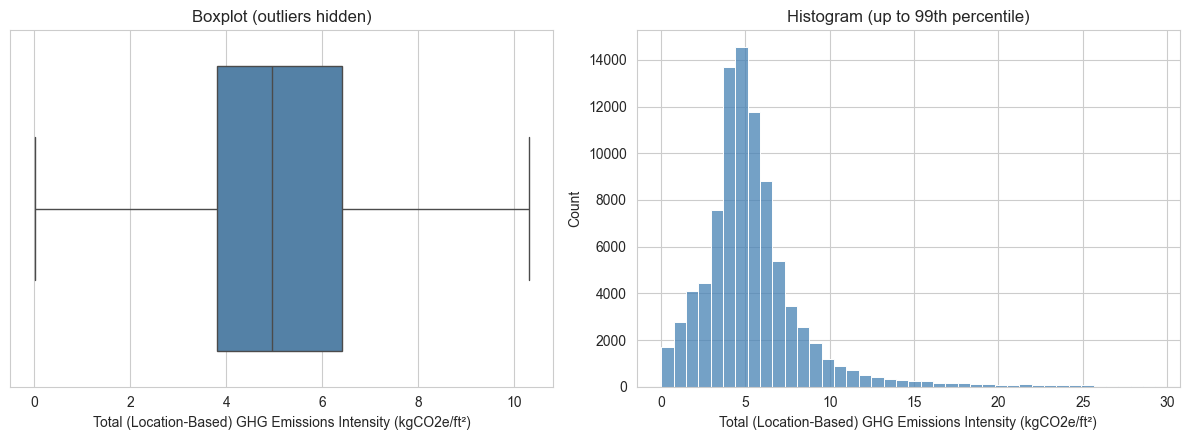

In [6]:
plot_target_distribution(model_df)

## Primary Evaluation: Year-Based Holdout

The main headline evaluation holds out the most recent year (`2024`) as the test set. All models are trained and evaluated on the **raw target scale** only. The forecasting track also includes a tuned random forest so the tuned and untuned versions can be compared directly.


In [7]:
scenario_order = [
    "forecasting_strict",
    "estimation_without_intensities",
    "fuel_derived_only",
    "estimation_full",
]

year_evaluations = {}
for scenario_name in scenario_order:
    year_evaluations[scenario_name] = run_split_evaluation(
        model_df,
        scenario_name,
        feature_scenarios[scenario_name],
        split_kind="year",
        holdout_year=PRIMARY_HOLDOUT_YEAR,
    )

forecasting_tuned_row, forecasting_tuned_artifact, forecasting_tuned_search = tune_random_forest_model(
    year_evaluations["forecasting_strict"]["X_train"],
    year_evaluations["forecasting_strict"]["X_test"],
    year_evaluations["forecasting_strict"]["y_train"],
    year_evaluations["forecasting_strict"]["y_test"],
    feature_scenarios["forecasting_strict"]["numeric"],
    feature_scenarios["forecasting_strict"]["categorical"],
    model_name="TunedRandomForestRegressor (Forecasting)",
    min_category_count=MIN_CATEGORY_COUNT,
    rf_random_state=42,
    n_iter=8,
    cv=3,
)

forecasting_eval = year_evaluations["forecasting_strict"]
forecasting_eval["artifacts"][forecasting_tuned_artifact.name] = forecasting_tuned_artifact
forecasting_eval["results_df"] = pd.concat(
    [
        forecasting_eval["results_df"],
        pd.DataFrame([{
            "Scenario": "forecasting_strict",
            "Split": "year",
            **forecasting_tuned_row,
        }]),
    ],
    ignore_index=True,
).sort_values(["RMSE", "MAE"]).reset_index(drop=True)
forecasting_eval["tuned_rf_search"] = forecasting_tuned_search
forecasting_eval["tuned_rf_best_params"] = forecasting_tuned_search.best_params_

year_results_df = pd.concat(
    [evaluation["results_df"] for evaluation in year_evaluations.values()],
    ignore_index=True,
)
year_results_df["Scenario Label"] = year_results_df["Scenario"].map(SCENARIO_LABELS)

print(f"Primary holdout year: {PRIMARY_HOLDOUT_YEAR}")
print("Training-scope filtering: rows above the training 99th-percentile target are removed after the split.")
for scenario_name in scenario_order:
    evaluation = year_evaluations[scenario_name]
    print(
        f"- {SCENARIO_LABELS[scenario_name]}: scope_upper={evaluation['scope_upper']:.4f}, "
        f"train_rows_removed={evaluation['train_rows_removed']}, test_rows_removed={evaluation['test_rows_removed']}"
    )
print()
print("All year-holdout results:")
display(year_results_df)
print()
print("RMSE by model and scenario:")
display(year_results_df.pivot_table(index="Model", columns="Scenario Label", values="RMSE"))
print()
print("R2 by model and scenario:")
display(year_results_df.pivot_table(index="Model", columns="Scenario Label", values="R2"))

best_forecasting_model_name, best_forecasting_row, best_forecasting_artifact = select_best_learned_model(
    year_evaluations["forecasting_strict"]
)
best_estimation_model_name, best_estimation_row, best_estimation_artifact = select_best_learned_model(
    year_evaluations["estimation_full"]
)

print("Best year-holdout forecasting model:")
display(best_forecasting_row.to_frame().T)
print()
print("Tuned forecasting random forest best parameters:")
display(pd.DataFrame([forecasting_eval["tuned_rf_best_params"]]))
print()
print("Tuned forecasting random forest year-holdout metrics:")
display(
    forecasting_eval["results_df"]
    .loc[forecasting_eval["results_df"]["Model"] == "TunedRandomForestRegressor (Forecasting)"]
    .reset_index(drop=True)
)
print()
print("Best year-holdout estimation model:")
display(best_estimation_row.to_frame().T)




Primary holdout year: 2024
Training-scope filtering: rows above the training 99th-percentile target are removed after the split.
- Forecasting (Metadata Only): scope_upper=27.4770, train_rows_removed=595, test_rows_removed=400
- Estimation Without Intensities: scope_upper=27.4770, train_rows_removed=595, test_rows_removed=400
- Fuel-Derived Only: scope_upper=27.4770, train_rows_removed=595, test_rows_removed=400
- Estimation Full: scope_upper=27.4770, train_rows_removed=595, test_rows_removed=400

All year-holdout results:


,Scenario,Split,Model,MAE,RMSE,R2,Pred Min,Pred 99.5%,Pred Max,Scenario Label
0,forecasting_strict,year,RandomForestRegressor (Raw),1.406941,2.362249,0.471837,0.350435,15.238336,21.191512,Forecasting (Metadata Only)
1,forecasting_strict,year,TunedRandomForestRegressor (Forecasting),1.709308,2.644012,0.338327,0.423746,15.029470,21.541017,Forecasting (Metadata Only)
2,forecasting_strict,year,PropertyTypeMeanBaseline,1.888477,2.894497,0.207019,0.300000,15.343333,19.063158,Forecasting (Metadata Only)
3,forecasting_strict,year,LinearRegression (Raw),1.946398,2.956228,0.172834,0.000000,9.904007,15.294577,Forecasting (Metadata Only)
4,forecasting_strict,year,Ridge (Raw),1.946486,2.956260,0.172816,0.000000,9.902746,15.294852,Forecasting (Metadata Only)
5,estimation_without_intensities,year,RandomForestRegressor (Raw),1.336108,2.273803,0.510647,0.212729,15.638610,22.373834,Estimation Without Intensities
6,estimation_without_intensities,year,LinearRegression (Raw),1.842072,2.827748,0.243170,0.000000,11.914778,16.520101,Estimation Without Intensities
7,estimation_without_intensities,year,Ridge (Raw),1.842121,2.827778,0.243154,0.000000,11.915295,16.519911,Estimation Without Intensities
8,estimation_without_intensities,year,PropertyTypeMeanBaseline,1.888477,2.894497,0.207019,0.300000,15.343333,19.063158,Estimation Without Intensities
9,fuel_derived_only,year,Ridge (Raw),0.449906,0.704070,0.953081,0.057435,19.660084,31.568502,Fuel-Derived Only



RMSE by model and scenario:


Scenario Label,Estimation Full,Estimation Without Intensities,Forecasting (Metadata Only),Fuel-Derived Only
Model,,,,
LinearRegression (Raw),0.693247,2.827748,2.956228,0.704072
PropertyTypeMeanBaseline,2.894497,2.894497,2.894497,NaN
RandomForestRegressor (Raw),0.461955,2.273803,2.362249,0.729286
Ridge (Raw),0.693177,2.827778,2.956260,0.704070
TunedRandomForestRegressor (Forecasting),NaN,NaN,2.644012,NaN



R2 by model and scenario:


...

,model__n_estimators,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth
0,200,5,1,None,20



Tuned forecasting random forest year-holdout metrics:


,Scenario,Split,Model,MAE,RMSE,R2,Pred Min,Pred 99.5%,Pred Max
0,forecasting_strict,year,TunedRandomForestRegressor (Forecasting),1.709308,2.644012,0.338327,0.423746,15.02947,21.541017



Best year-holdout estimation model:


,Scenario,Split,Model,MAE,RMSE,R2,Pred Min,Pred 99.5%,Pred Max
0,estimation_full,year,RandomForestRegressor (Raw),0.204704,0.461955,0.979802,0.1,20.873922,26.204294


### Plot Setup

The next cells separate the year-holdout plots into smaller blocks so the forecasting, fuel-derived-only, and estimation views can be interpreted independently.


In [8]:
forecasting_prediction_map = {
    name: artifact.predictions
    for name, artifact in year_evaluations["forecasting_strict"]["artifacts"].items()
}
estimation_prediction_map = {
    name: artifact.predictions
    for name, artifact in year_evaluations["estimation_full"]["artifacts"].items()
}

fuel_derived_prediction_map = {
    name: artifact.predictions
    for name, artifact in year_evaluations["fuel_derived_only"]["artifacts"].items()
}


### Forecasting Comparison: Model Walkthrough

This section is the main visual explanation for the **forecasting** track. The models only use metadata and property-type features, so this is the harder and more defensible version of the problem.

Read the section in this order:

1. The table ranks forecasting models by `RMSE` on the 2024 holdout.
2. The first plot compares the baseline, linear model, selected random forest, and tuned random forest. `Ridge` is omitted from the plot because it behaves almost the same as `LinearRegression`.
3. The second plot isolates the untuned vs tuned random forest. The tuned version is shown as a tuning check, but it is not selected because it generalizes worse to 2024.

The red dashed line is perfect prediction. Points below the line are underpredictions; points above the line are overpredictions.


,Model,MAE,RMSE,R2,Pred 99.5%,Pred Max,Selected
0,RandomForestRegressor (Raw),1.4069,2.3622,0.4718,15.2383,21.1915,True
1,TunedRandomForestRegressor (Forecasting),1.7093,2.6440,0.3383,15.0295,21.5410,False
2,PropertyTypeMeanBaseline,1.8885,2.8945,0.2070,15.3433,19.0632,False
3,LinearRegression (Raw),1.9464,2.9562,0.1728,9.9040,15.2946,False
4,Ridge (Raw),1.9465,2.9563,0.1728,9.9027,15.2949,False


Tuned RF RMSE is 0.2818 higher than the untuned RF on the 2024 holdout, so the untuned RF remains the selected forecasting model.


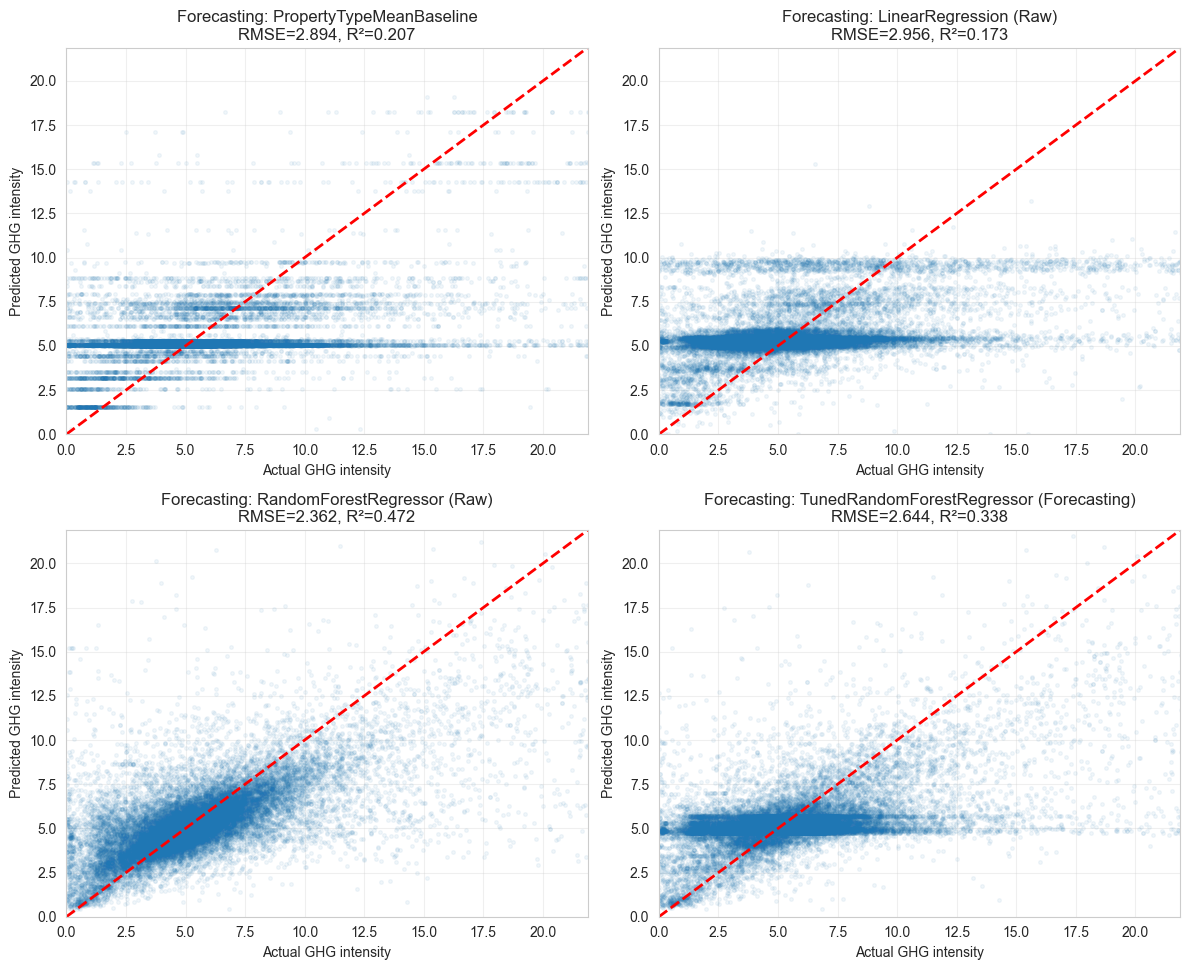

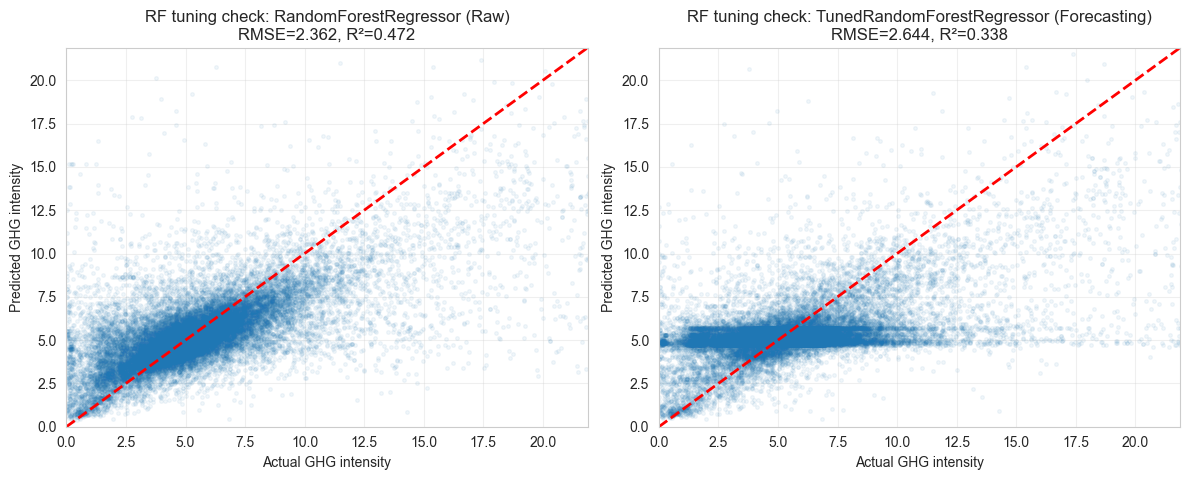

In [9]:
forecasting_results_for_walkthrough = (
    year_evaluations["forecasting_strict"]["results_df"]
    .loc[:, ["Model", "MAE", "RMSE", "R2", "Pred 99.5%", "Pred Max"]]
    .assign(Selected=lambda frame: frame["Model"].eq(best_forecasting_model_name))
    .sort_values(["RMSE", "MAE"])
    .reset_index(drop=True)
)

display(forecasting_results_for_walkthrough.round(4))

untuned_rf_row = forecasting_results_for_walkthrough.loc[
    forecasting_results_for_walkthrough["Model"] == "RandomForestRegressor (Raw)"
].iloc[0]
tuned_rf_row = forecasting_results_for_walkthrough.loc[
    forecasting_results_for_walkthrough["Model"] == "TunedRandomForestRegressor (Forecasting)"
].iloc[0]
tuned_rmse_delta = tuned_rf_row["RMSE"] - untuned_rf_row["RMSE"]
print(
    f"Tuned RF RMSE is {tuned_rmse_delta:.4f} higher than the untuned RF "
    f"on the 2024 holdout, so the untuned RF remains the selected forecasting model."
)

forecasting_walkthrough_models = [
    "PropertyTypeMeanBaseline",
    "LinearRegression (Raw)",
    "RandomForestRegressor (Raw)",
    "TunedRandomForestRegressor (Forecasting)",
]
plot_prediction_grid_with_metrics(
    year_evaluations["forecasting_strict"],
    forecasting_walkthrough_models,
    title_prefix="Forecasting",
    ncols=2,
)

plot_prediction_grid_with_metrics(
    year_evaluations["forecasting_strict"],
    ["RandomForestRegressor (Raw)", "TunedRandomForestRegressor (Forecasting)"],
    title_prefix="RF tuning check",
    ncols=2,
)


### Estimation Comparison Plots

These plots use the **estimation / imputation** track, which includes fuel-derived features. That makes the problem easier, so stronger diagonal alignment is expected.

- If these plots are much tighter than the forecasting plots, the notebook is showing that fuel-use variables carry most of the predictive signal.
- This is the visual counterpart to the feature ablation and near-reconstruction checks.


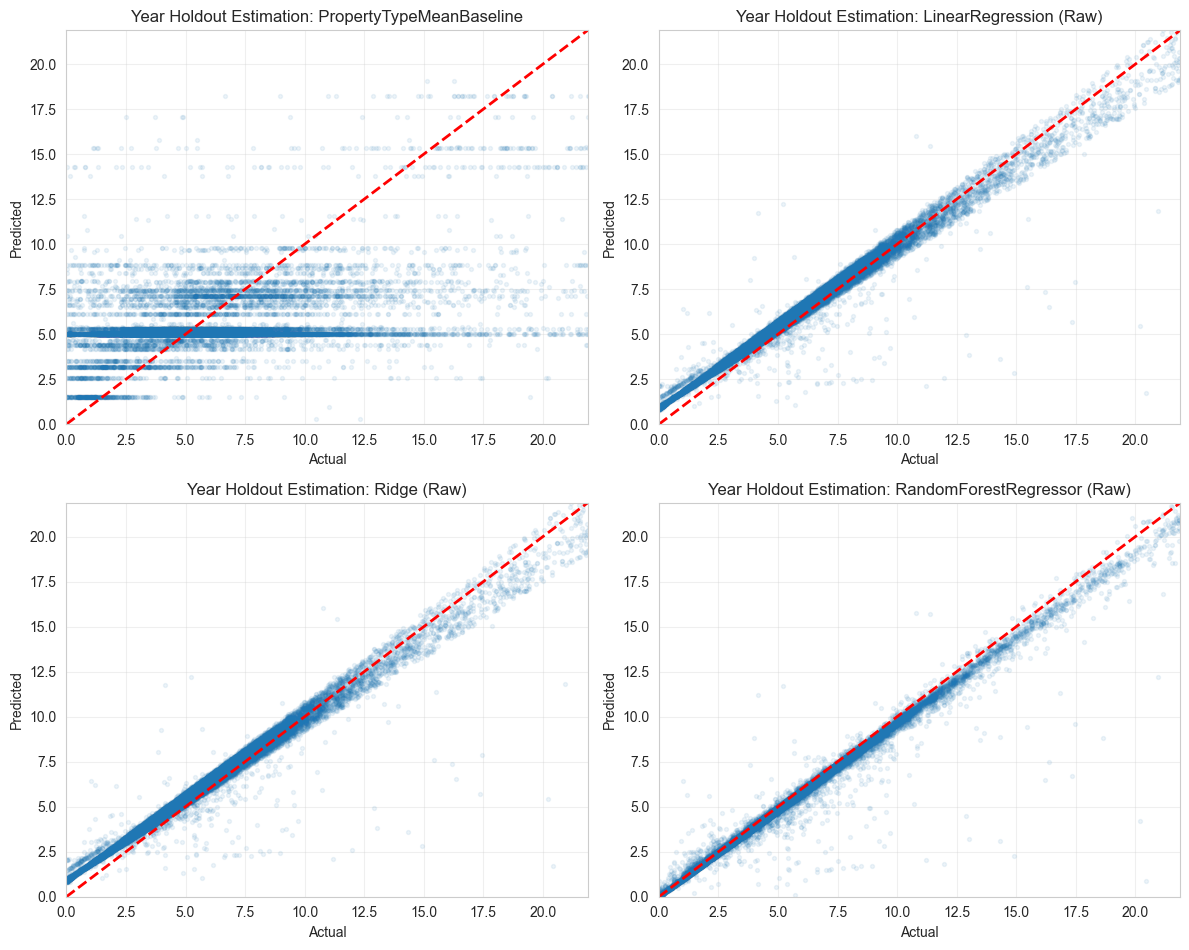

In [10]:
plot_prediction_grid(
    year_evaluations["estimation_full"]["y_test"],
    estimation_prediction_map,
    title_prefix="Year Holdout Estimation",
    ncols=2,
)


### Fuel-Derived-Only Comparison Plots

These plots isolate the `fuel_derived_only` scenario, which uses fuel intensities, shares, and missingness flags without the metadata-style building features.

- This section helps show how much predictive signal comes from fuel-derived variables alone.
- If these plots are much tighter than the forecasting plots, then the fuel variables are carrying most of the model performance.
- Comparing this block against the full estimation block shows whether metadata adds much beyond fuel-derived inputs.


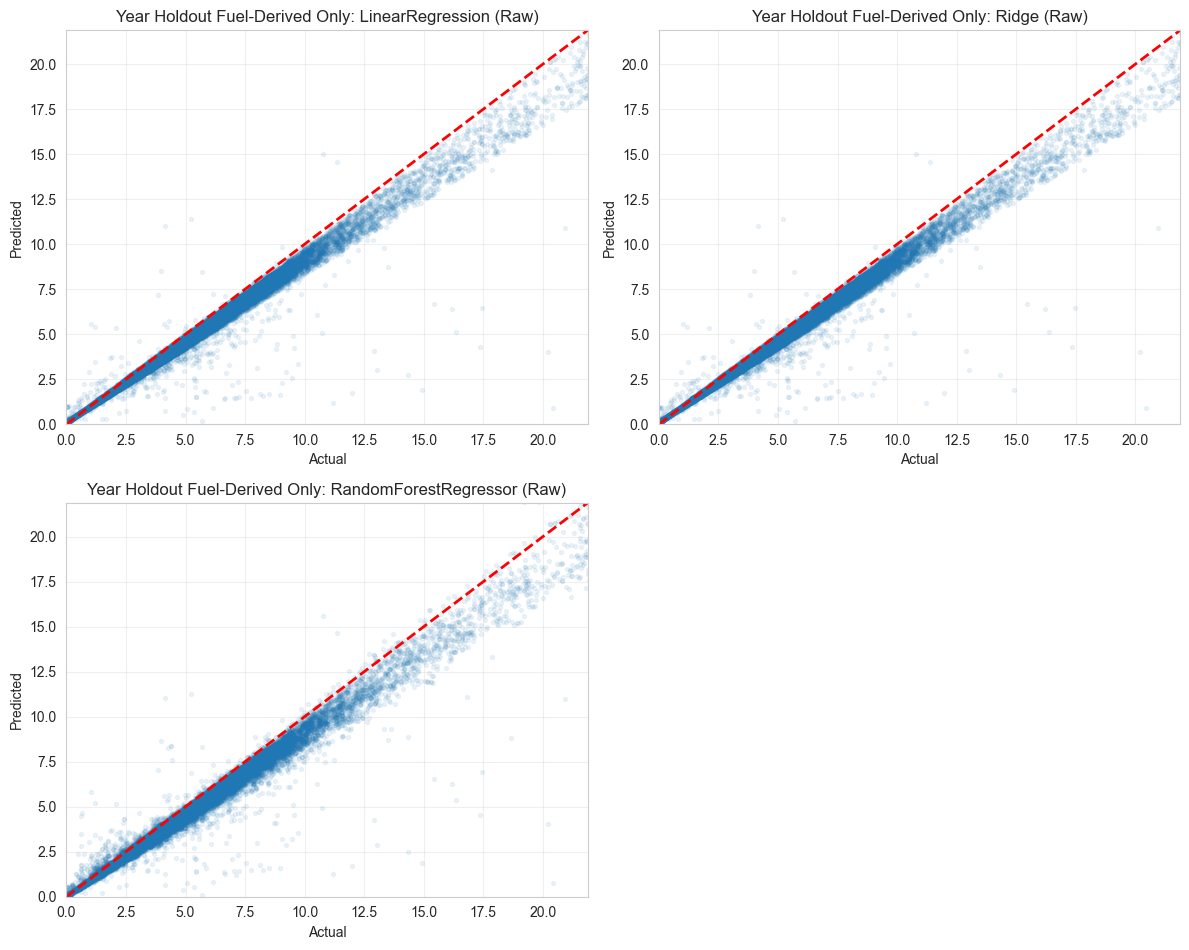

In [11]:
plot_prediction_grid(
    year_evaluations["fuel_derived_only"]["y_test"],
    fuel_derived_prediction_map,
    title_prefix="Year Holdout Fuel-Derived Only",
    ncols=2,
)


### Best Forecasting Model Diagnostics

This diagnostic block zooms in on the best forecasting model only.

- `Actual vs Predicted` checks overall calibration.
- `Residuals vs Actual` shows whether errors change with target size.
- `Residual Distribution` shows whether the model is centered near zero error or systematically biased.
- Negative residuals mean the model is **underpredicting**; positive residuals mean it is **overpredicting**.


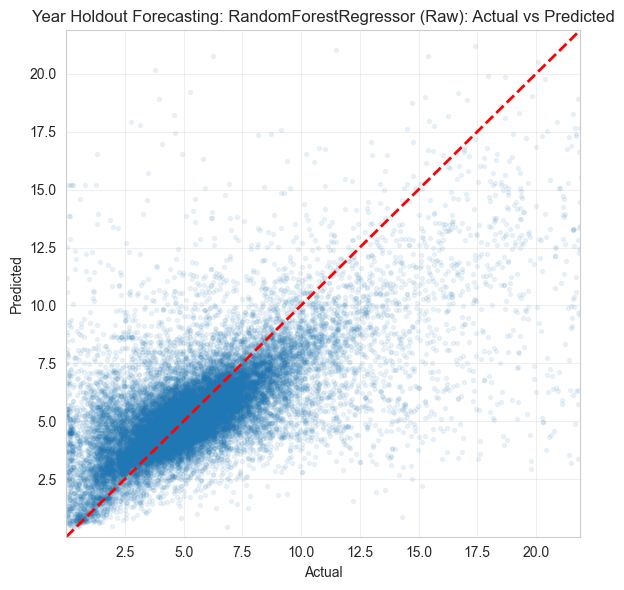

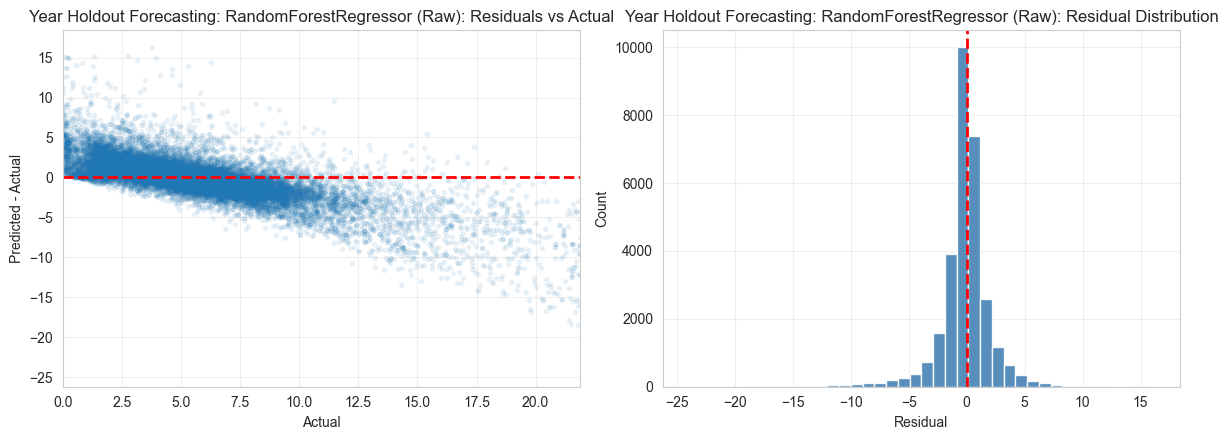

In [12]:
plot_model_diagnostics(
    year_evaluations["forecasting_strict"],
    best_forecasting_model_name,
    title_prefix=f"Year Holdout Forecasting: {best_forecasting_model_name}",
)


### Best Estimation Model Diagnostics

This is the same diagnostic view for the best estimation model. Because fuel-derived variables are included, this model should usually fit more tightly, but the residual plots still matter.

- A centered residual histogram suggests low overall bias.
- A downward residual trend would mean high-emission buildings are still being underpredicted.
- Comparing this block to the forecasting diagnostics shows how much the extra fuel information changes model behavior.


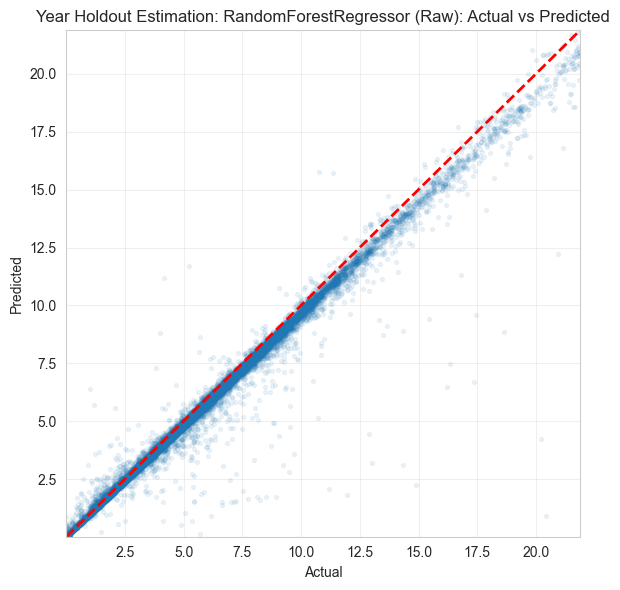

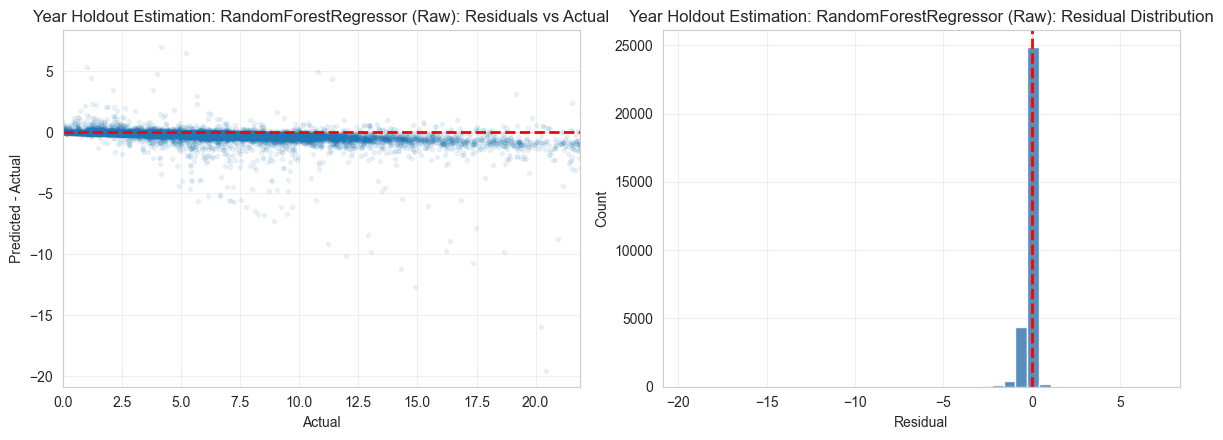

In [13]:
plot_model_diagnostics(
    year_evaluations["estimation_full"],
    best_estimation_model_name,
    title_prefix=f"Year Holdout Estimation: {best_estimation_model_name}",
)


## Feature-Scenario Ablation And Near-Reconstruction Check

These checks answer the core modeling question directly on the **raw target scale**:

- how much performance comes from building metadata alone?
- how much comes from fuel-derived variables?
- are the strongest results actually forecasting, or are they closer to emissions reconstruction / imputation?


Year-holdout reconstruction results using fuel intensities only:


,Model,MAE,RMSE,R2
0,Ridge (Fuel Intensities Only),0.451909,0.705674,0.952867
1,LinearRegression (Fuel Intensities Only),0.451909,0.705674,0.952867



Largest linear coefficients from fuel intensities only:


,Feature,Coefficient,Abs Coefficient
0,electricity_grid_purchase_intensity,0.095787,0.095787
1,fuel_oil_4_intensity,0.074226,0.074226
2,fuel_oil_2_intensity,0.072857,0.072857
3,fuel_oil_5_6_intensity,0.072753,0.072753
4,fuel_oil_1_intensity,0.071612,0.071612
5,district_steam_intensity,0.065183,0.065183
6,district_hot_water_intensity,0.064021,0.064021
7,natural_gas_intensity,0.051927,0.051927
8,diesel_2_intensity,0.051659,0.051659
9,district_chilled_water_intensity,0.042528,0.042528


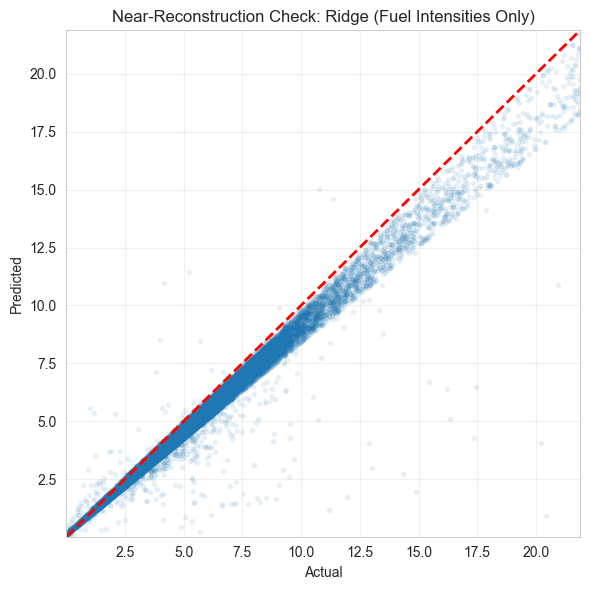

In [14]:
fuel_intensity_features = [col for col in numeric_features if col.endswith("_intensity")]
reconstruction_results_df, reconstruction_coef_df, reconstruction_models = run_near_reconstruction_check(
    model_df,
    fuel_intensity_features,
    split_kind="year",
    holdout_year=PRIMARY_HOLDOUT_YEAR,
)

print("Year-holdout reconstruction results using fuel intensities only:")
display(reconstruction_results_df)
print()
print("Largest linear coefficients from fuel intensities only:")
display(reconstruction_coef_df.head(12))
print()

best_reconstruction_key = reconstruction_results_df.iloc[0]["Model"]
plot_actual_vs_predicted_quantile(
    reconstruction_models[best_reconstruction_key]["y_test"],
    reconstruction_models[best_reconstruction_key]["y_pred"],
    title=f"Near-Reconstruction Check: {best_reconstruction_key}",
    upper_quantile=0.995,
)


## Secondary Stress Test: Grouped Holdout By Building ID

This split avoids putting the same building into both train and test, even if the building appears in multiple years.


In [15]:
group_scenarios = ["forecasting_strict", "estimation_full"]
group_evaluations = {}
for scenario_name in group_scenarios:
    group_evaluations[scenario_name] = run_split_evaluation(
        model_df,
        scenario_name,
        feature_scenarios[scenario_name],
        split_kind="group",
        group_col="Stable Building ID",
        test_size=GROUP_TEST_SIZE,
    )

group_results_df = pd.concat(
    [evaluation["results_df"] for evaluation in group_evaluations.values()],
    ignore_index=True,
)
group_results_df["Scenario Label"] = group_results_df["Scenario"].map(SCENARIO_LABELS)

print("Grouped-holdout results:")
display(group_results_df)
print()
print("Grouped-holdout RMSE by model and scenario:")
display(group_results_df.pivot_table(index="Model", columns="Scenario Label", values="RMSE"))
print()
print("Grouped-holdout R2 by model and scenario:")
display(group_results_df.pivot_table(index="Model", columns="Scenario Label", values="R2"))

best_group_estimation_model_name, best_group_estimation_row, best_group_estimation_artifact = select_best_learned_model(
    group_evaluations["estimation_full"]
)
print("Best grouped-holdout estimation model:")
display(best_group_estimation_row.to_frame().T)


Grouped-holdout results:


,Scenario,Split,Model,MAE,RMSE,R2,Pred Min,Pred 99.5%,Pred Max,Scenario Label
0,forecasting_strict,group,LinearRegression (Raw),1.865949,2.867649,0.196308,0.000000,13.948585,16.711814,Forecasting (Metadata Only)
1,forecasting_strict,group,Ridge (Raw),1.866027,2.867650,0.196308,0.000000,13.914942,16.673596,Forecasting (Metadata Only)
2,forecasting_strict,group,PropertyTypeMeanBaseline,1.874150,2.868708,0.195715,1.621563,16.333849,20.358077,Forecasting (Metadata Only)
3,forecasting_strict,group,RandomForestRegressor (Raw),1.889911,2.938316,0.156209,0.319380,15.839792,24.618951,Forecasting (Metadata Only)
4,estimation_full,group,RandomForestRegressor (Raw),0.110138,0.409396,0.983620,0.023168,22.595540,27.791617,Estimation Full
5,estimation_full,group,Ridge (Raw),0.224992,0.466440,0.978737,0.000000,22.369448,34.297168,Estimation Full
6,estimation_full,group,LinearRegression (Raw),0.224999,0.466461,0.978735,0.000000,22.369703,34.297592,Estimation Full
7,estimation_full,group,PropertyTypeMeanBaseline,1.874150,2.868708,0.195715,1.621563,16.333849,20.358077,Estimation Full



Grouped-holdout RMSE by model and scenario:


Scenario Label,Estimation Full,Forecasting (Metadata Only)
Model,,
LinearRegression (Raw),0.466461,2.867649
PropertyTypeMeanBaseline,2.868708,2.868708
RandomForestRegressor (Raw),0.409396,2.938316
Ridge (Raw),0.466440,2.867650



Grouped-holdout R2 by model and scenario:


Scenario Label,Estimation Full,Forecasting (Metadata Only)
Model,,
LinearRegression (Raw),0.978735,0.196308
PropertyTypeMeanBaseline,0.195715,0.195715
RandomForestRegressor (Raw),0.983620,0.156209
Ridge (Raw),0.978737,0.196308


Best grouped-holdout estimation model:


,Scenario,Split,Model,MAE,RMSE,R2,Pred Min,Pred 99.5%,Pred Max
0,estimation_full,group,RandomForestRegressor (Raw),0.110138,0.409396,0.98362,0.023168,22.59554,27.791617


## Subgroup Error Tables And Residual Diagnostics

The subgroup tables below are based on the **grouped-holdout estimation model**, because that test set spans all years and excludes repeated buildings from train/test overlap.


Property Type


,Property Type for Modeling,n,MAE,RMSE,R2,Pred Mean,Actual Mean
0,Other - Recreation,117,0.400146,1.479404,0.941436,8.235845,8.427607
1,College/University,166,0.303713,0.945040,0.946133,6.371997,6.401024
2,Mixed Use Property,137,0.317405,0.912628,0.972197,8.455808,8.368394
3,Retail Store,159,0.280033,0.801595,0.960969,6.491295,6.483836
4,Office,1510,0.164182,0.503233,0.971381,5.447030,5.437192
5,Manufacturing/Industrial Plant,237,0.111601,0.332573,0.992497,4.372400,4.363882
6,Multifamily Housing,11921,0.076064,0.277560,0.985777,5.105172,5.110061
7,K-12 School,1057,0.121524,0.276998,0.980359,4.910823,4.933387
8,Hotel,417,0.117049,0.235787,0.995089,7.363066,7.364053
9,Worship Facility,128,0.106692,0.222343,0.994909,4.235976,4.229531



Year


,Calendar Year,n,MAE,RMSE,R2,Pred Mean,Actual Mean
0,2024,5986,0.105437,0.433485,0.983642,5.594896,5.649544
1,2022,5791,0.117608,0.405769,0.982307,5.233084,5.215455
2,2023,6050,0.107639,0.387744,0.984631,5.390412,5.373339



Target Decile


,Target Decile,n,MAE,RMSE,R2,Pred Mean,Actual Mean
0,Target Decile 10,1783,0.372778,0.980168,0.949647,12.298454,12.440679
1,Target Decile 9,1783,0.134269,0.431515,0.241507,7.490617,7.539372
2,Target Decile 1,1783,0.105520,0.343643,0.670390,1.404872,1.326181
3,Target Decile 4,1783,0.068222,0.327316,-5.162535,4.286989,4.270869
4,Target Decile 6,1782,0.073468,0.268655,-3.190583,5.140380,5.143996
5,Target Decile 8,1782,0.081630,0.251526,-0.020361,6.355810,6.360825
6,Target Decile 2,1783,0.077154,0.242731,0.517388,2.962825,2.926450
7,Target Decile 7,1783,0.069983,0.225960,-0.806498,5.649447,5.660241
8,Target Decile 5,1783,0.058573,0.184796,-1.075841,4.706639,4.710516
9,Target Decile 3,1782,0.059720,0.155337,0.153983,3.783106,3.768288



Floor Area Decile


,Floor Area Decile,n,MAE,RMSE,R2,Pred Mean,Actual Mean
0,Floor Area Decile 10,1783,0.170626,0.649837,0.972655,6.119720,6.138744
1,Floor Area Decile 1,1783,0.141607,0.560389,0.984042,6.161647,6.153752
2,Floor Area Decile 3,1782,0.103004,0.459882,0.976382,5.340141,5.352969
3,Floor Area Decile 4,1783,0.104708,0.420306,0.978835,5.371861,5.384599
4,Floor Area Decile 5,1783,0.093874,0.346574,0.984179,5.221344,5.214762
5,Floor Area Decile 6,1782,0.092642,0.327858,0.982564,5.118342,5.137329
6,Floor Area Decile 8,1782,0.102403,0.317120,0.988316,5.138880,5.142413
7,Floor Area Decile 7,1783,0.093418,0.311258,0.985463,4.979054,4.985603
8,Floor Area Decile 9,1783,0.113060,0.292689,0.989112,5.012669,5.033427
9,Floor Area Decile 2,1783,0.086020,0.202023,0.996409,5.615660,5.604021


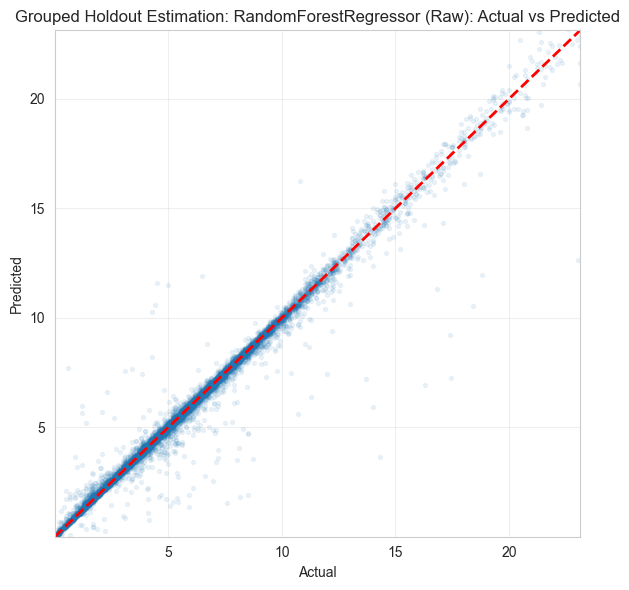

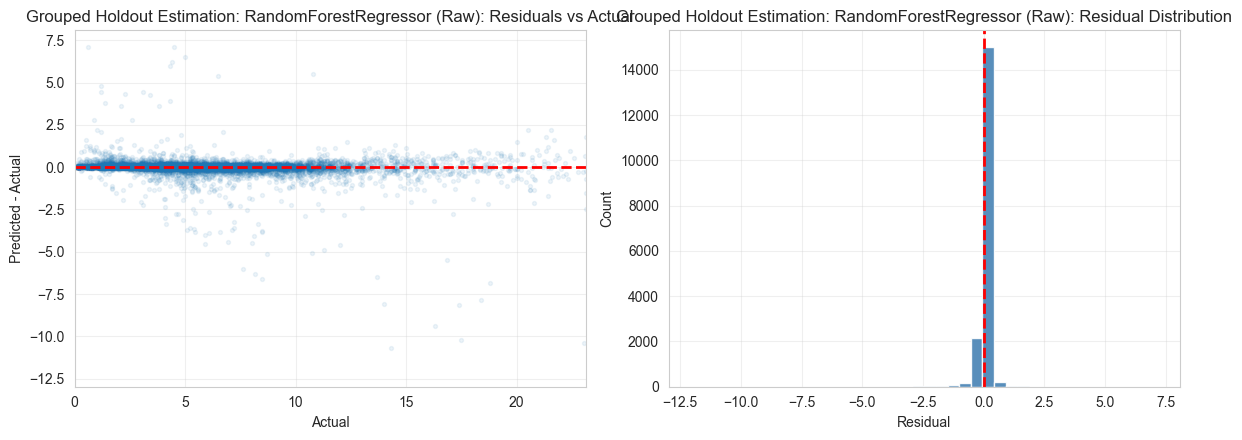

In [16]:
group_estimation_frame = build_prediction_frame_for_model(
    group_evaluations["estimation_full"],
    best_group_estimation_model_name,
)
group_subgroup_reports = build_subgroup_reports(group_estimation_frame)

for report_name, report_df in group_subgroup_reports.items():
    print(report_name)
    display(report_df.head(15))
    print()

plot_model_diagnostics(
    group_evaluations["estimation_full"],
    best_group_estimation_model_name,
    title_prefix=f"Grouped Holdout Estimation: {best_group_estimation_model_name}",
)


## Permutation Importance

Permutation importance is used as the main interpretation layer because it is robust on this notebook’s large one-hot-expanded feature space and sampled holdout evaluation.


In [17]:
forecasting_permutation_df = permutation_importance_report(
    best_forecasting_artifact.model,
    year_evaluations["forecasting_strict"]["X_test"],
    year_evaluations["forecasting_strict"]["y_test"],
    sample_size=PERMUTATION_SAMPLE_SIZE,
)

estimation_permutation_df = permutation_importance_report(
    best_estimation_artifact.model,
    year_evaluations["estimation_full"]["X_test"],
    year_evaluations["estimation_full"]["y_test"],
    sample_size=PERMUTATION_SAMPLE_SIZE,
)

print("Top permutation importances: forecasting track")
display(forecasting_permutation_df.head(20))
print()
print("Top permutation importances: estimation track")
display(estimation_permutation_df.head(20))


/Users/jimhe/Documents/sjsu/DATA245/GroupProject/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Top permutation importances: forecasting track


,Feature,Importance Mean,Importance Std
0,Property Type for Modeling,7.637733e-01,5.458398e-02
1,Model GFA (ft²),5.595080e-01,5.056787e-02
2,Year Built,4.905188e-01,2.145782e-02
3,Largest Use Share of GFA,1.415559e-01,1.589885e-02
4,Occupancy,6.993127e-02,1.826005e-02
5,Number of Buildings,1.571987e-02,5.625212e-03
6,Calendar Year,-8.881784e-17,1.776357e-16



Top permutation importances: estimation track


,Feature,Importance Mean,Importance Std
0,electricity_grid_purchase_intensity,4.454879e+00,4.347692e-02
1,electricity_grid_purchase_share,2.871931e+00,5.218150e-02
2,natural_gas_intensity,2.146817e+00,6.132507e-02
3,fuel_oil_2_intensity,7.652257e-01,8.431770e-02
4,natural_gas_share,3.887089e-01,3.199680e-03
5,fuel_oil_2_share,3.656581e-01,1.227862e-02
6,fuel_oil_4_intensity,3.006964e-01,2.090216e-02
7,fuel_oil_4_share,1.117428e-01,3.180166e-03
8,district_steam_intensity,2.529339e-02,3.080772e-03
9,Largest Use Share of GFA,1.112600e-03,9.607132e-04


## Is This Notebook Solving Forecasting, Imputation, Or Both?

In [18]:
scope_summary_df = pd.DataFrame([
    {
        "Track": "Forecasting",
        "Feature Scope": "Metadata and property-type information only",
        "Best Model": best_forecasting_model_name,
        "Holdout": f"Year holdout ({PRIMARY_HOLDOUT_YEAR})",
        "RMSE": best_forecasting_row["RMSE"],
        "R2": best_forecasting_row["R2"],
        "Interpretation": "This is the cleaner pre-disclosure forecasting test.",
    },
    {
        "Track": "Estimation / Imputation",
        "Feature Scope": "Metadata plus fuel-derived intensities, shares, and missingness flags",
        "Best Model": best_estimation_model_name,
        "Holdout": f"Year holdout ({PRIMARY_HOLDOUT_YEAR})",
        "RMSE": best_estimation_row["RMSE"],
        "R2": best_estimation_row["R2"],
        "Interpretation": "This is the stronger predictive track, but it is much closer to emissions estimation than pure forecasting.",
    },
])

display(scope_summary_df)
print(
    "Conclusion: the notebook now addresses both tasks, but the highest scores come from the estimation/imputation track. "
    "The forecasting track is the more defensible answer to whether building characteristics alone can predict GHG intensity."
)


,Track,Feature Scope,Best Model,Holdout,RMSE,R2,Interpretation
0,Forecasting,Metadata and property-type information only,RandomForestRegressor (Raw),Year holdout (2024),2.362249,0.471837,This is the cleaner pre-disclosure forecasting...
1,Estimation / Imputation,"Metadata plus fuel-derived intensities, shares...",RandomForestRegressor (Raw),Year holdout (2024),0.461955,0.979802,"This is the stronger predictive track, but it ..."


Conclusion: the notebook now addresses both tasks, but the highest scores come from the estimation/imputation track. The forecasting track is the more defensible answer to whether building characteristics alone can predict GHG intensity.


## Saved Forecasting Model Artifact

This section saves the best year-holdout forecasting pipeline to `jim_tuned_rf_pipeline.pkl`, matching the saved-model convention used by the Streamlit demo. The pickle stores the fitted preprocessing pipeline and model directly, while a small JSON sidecar records the metrics and feature columns.


In [19]:
JIM_FORECAST_MODEL_PATH = Path("jim_tuned_rf_pipeline.pkl")
JIM_FORECAST_METADATA_PATH = Path("jim_tuned_rf_pipeline_metadata.json")


def save_pipeline_pickle(model, path: Path) -> Path:
    """Save fitted sklearn pipelines, including notebook-defined transformers."""

    path = Path(path)
    try:
        import cloudpickle

        with path.open("wb") as file:
            cloudpickle.dump(model, file)
    except ImportError:
        import joblib

        joblib.dump(model, path, compress=3)
    return path


def load_pipeline_pickle(path: Path):
    """Load the saved pipeline artifact for a quick smoke test or demo use."""

    import joblib

    return joblib.load(Path(path))


def build_forecast_artifact_metadata() -> dict:
    return {
        "model_name": best_forecasting_model_name,
        "scenario": "forecasting_strict",
        "scenario_label": SCENARIO_LABELS["forecasting_strict"],
        "target": TARGET,
        "holdout_year": int(PRIMARY_HOLDOUT_YEAR),
        "feature_columns": list(year_evaluations["forecasting_strict"]["feature_columns"]),
        "numeric_features": list(feature_scenarios["forecasting_strict"]["numeric"]),
        "categorical_features": list(feature_scenarios["forecasting_strict"]["categorical"]),
        "scope_upper": float(year_evaluations["forecasting_strict"]["scope_upper"]),
        "train_rows": int(len(year_evaluations["forecasting_strict"]["X_train"])),
        "test_rows": int(len(year_evaluations["forecasting_strict"]["X_test"])),
        "metrics": {
            "MAE": float(best_forecasting_row["MAE"]),
            "RMSE": float(best_forecasting_row["RMSE"]),
            "R2": float(best_forecasting_row["R2"]),
            "Pred Min": float(best_forecasting_row["Pred Min"]),
            "Pred 99.5%": float(best_forecasting_row["Pred 99.5%"]),
            "Pred Max": float(best_forecasting_row["Pred Max"]),
        },
    }


def export_best_forecast_pipeline(
    model_path: Path = JIM_FORECAST_MODEL_PATH,
    metadata_path: Path = JIM_FORECAST_METADATA_PATH,
) -> tuple[Path, Path, dict]:
    metadata = build_forecast_artifact_metadata()
    save_pipeline_pickle(best_forecasting_artifact.model, model_path)
    Path(metadata_path).write_text(json.dumps(metadata, indent=2))
    return Path(model_path), Path(metadata_path), metadata


def build_sample_forecast_input() -> pd.DataFrame:
    return pd.DataFrame([
        {
            "Calendar Year": PRIMARY_HOLDOUT_YEAR,
            "Year Built": 1980,
            "Number of Buildings": 1,
            "Occupancy": 95.0,
            "Model GFA (ft²)": 50000.0,
            "Largest Use Share of GFA": 0.9,
            "Property Type for Modeling": "Multifamily Housing",
        }
    ])


forecast_model_path, forecast_metadata_path, forecast_metadata = export_best_forecast_pipeline()
loaded_forecast_model = load_pipeline_pickle(forecast_model_path)
sample_forecast_input = build_sample_forecast_input()
sample_forecast_prediction = float(loaded_forecast_model.predict(sample_forecast_input)[0])

print(f"Saved forecasting model pipeline to: {forecast_model_path}")
print(f"Saved forecasting model metadata to: {forecast_metadata_path}")
print(f"Loaded model smoke-test prediction: {sample_forecast_prediction:.2f} kgCO2e/ft²")
display(pd.DataFrame([forecast_metadata["metrics"]]))


Saved forecasting model pipeline to: jim_tuned_rf_pipeline.pkl
Saved forecasting model metadata to: jim_tuned_rf_pipeline_metadata.json
Loaded model smoke-test prediction: 6.76 kgCO2e/ft²


,MAE,RMSE,R2,Pred Min,Pred 99.5%,Pred Max
0,1.406941,2.362249,0.471837,0.350435,15.238336,21.191512
